In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from neural_network.RNN.rnn import RNN
from modules.lstm_rnn import LSTM
from modules.simple_rnn import Simple_RNN
from functions.utilities import prepare_sequence_data
from modules.dense_layer import Dense 
from modules.activation_layer import Activation
from modules.embedding import Embedding
from modules.dropout import Dropout


In [10]:
df = pd.read_csv("data/train_emoji.csv")
print(df)
df.drop(df.columns[[2, 3]], axis=1, inplace=True)
print(df)

              never talk to me again  3  Unnamed: 2 Unnamed: 3
0    I am proud of your achievements  2         NaN        NaN
1     It is the worst day in my life  3         NaN        NaN
2                   Miss you so much  0         NaN        [0]
3                       food is life  4         NaN        NaN
4                     I love you mum  0         NaN        NaN
..                               ... ..         ...        ...
126        he had to make a home run  1         NaN        NaN
127               I am ordering food  4         NaN        NaN
128           What is wrong with you  3         NaN        NaN
129                       I love you  0         NaN        NaN
130                        great job  2         NaN        NaN

[131 rows x 4 columns]
              never talk to me again  3
0    I am proud of your achievements  2
1     It is the worst day in my life  3
2                   Miss you so much  0
3                       food is life  4
4                   

In [11]:
X_train = df.iloc[:, 0].to_numpy()
Y_train = df.iloc[:, 1].to_numpy()

print(X_train.shape)
print(X_train)
print(Y_train.shape)
print(Y_train)

maxLen = len(max(X_train, key=lambda x: len(x.split())).split())
print(maxLen)

(131,)
['I am proud of your achievements' 'It is the worst day in my life'
 'Miss you so much' 'food is life' 'I love you mum' 'Stop saying bullshit'
 'congratulations on your acceptance' 'The assignment is too long '
 'I want to go play' 'she did not answer my text '
 'Your stupidity has no limit' 'how many points did he score'
 'my algorithm performs poorly' 'I got approved' 'Stop shouting at me'
 'Sounds like a fun plan ha ha' 'no one likes him'
 'the game just finished' 'I will celebrate soon'
 'So sad you are not coming' 'She is my dearest love' 'Good job'
 'It was funny lol' 'candy is life ' 'The chicago cubs won again'
 'I am hungry' 'I am so excited to see you after so long'
 'you did well on you exam' 'lets brunch some day' 'he is so cute'
 'How dare you ask that' 'do you want to join me for dinner ' 'I said yes'
 'she is attractive' 'you suck' 'she smiles a lot' 'he is laughing'
 'she takes forever to get ready ' 'French macaroon is so tasty'
 'we made it' 'I am excited' 'I a

In [12]:
df_test = pd.read_csv('data/tesss.csv')
X_test = df_test.iloc[:, 0].to_numpy()
Y_test = df_test.iloc[:, 1].to_numpy()

print(X_test.shape)
print(X_test)
print(Y_test.shape)
print(Y_test)

(55,)
['he did not answer\t' 'he got a very nice raise\t'
 'she got me a nice present\t' 'ha ha ha it was so funny\t'
 'he is a good friend\t' 'I am upset\t'
 'We had such a lovely dinner tonight\t' 'where is the food\t'
 'Stop making this joke ha ha ha\t' 'where is the ball\t' 'work is hard\t'
 'This girl is messing with me\t' 'are you serious'
 'Let us go play baseball\t' 'This stupid grader is not working \t'
 'work is horrible\t' 'Congratulation for having a baby\t'
 'stop pissing me off' 'any suggestions for dinner\t'
 'I love taking breaks\t' 'you brighten my day\t' 'I boiled rice\t'
 'she is a bully\t' 'Why are you feeling bad\t' 'I am upset\t'
 'give me the ball' 'My grandmother is the love of my life\t'
 'enjoy your game' 'valentine day is near\t' 'I miss you so much\t'
 'throw the ball\t' 'My life is so boring\t' 'she said yes\t'
 'will you be my valentine\t' 'he can pitch really well\t'
 'dance with me\t' 'I am hungry' 'See you at the restaurant\t'
 'I like to laugh\t' 'I wi

In [13]:
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)]
    return Y

def read_glove_vecs(glove_file):
    with open(glove_file, 'r', encoding='utf-8') as f:
        words = set()
        word_to_vec_map = {}
        for line in f:
            line = line.strip().split()
            curr_word = line[0]
            words.add(curr_word)
            word_to_vec_map[curr_word] = np.array(line[1:], dtype=np.float64)
        
        i = 1
        words_to_index = {}
        index_to_words = {}
        for w in sorted(words):
            words_to_index[w] = i
            index_to_words[i] = w
            i = i + 1
    return words_to_index, index_to_words, word_to_vec_map

word_to_index, index_to_word, word_to_vec_map = read_glove_vecs('data/glove.6B.50d.txt')

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42
)

X_train_indices = np.zeros((X_train.shape[0], maxLen))
for i in range(X_train.shape[0]):
    sentence_words = X_train[i].lower().split()
    j = 0

    for w in sentence_words:
        if w in word_to_index:
            X_train_indices[i, j] = word_to_index[w]
            j += 1

X_val_indices = np.zeros((X_val.shape[0], maxLen))
for i in range(X_val.shape[0]):
    sentence_words = X_val[i].lower().split()
    j = 0

    for w in sentence_words:
        if w in word_to_index:
            X_val_indices[i, j] = word_to_index[w]
            j += 1

print(X_train_indices.shape)
print(X_train_indices)
print(X_val_indices.shape)
print(X_val_indices)

(104, 10)
[[175199. 222494.  69714. ...      0.      0.      0.]
 [126552. 394475. 222471. ...      0.      0.      0.]
 [185457.  52943. 293982. ...      0.      0.      0.]
 ...
 [343812. 329947.  62065. ...      0.      0.      0.]
 [185457. 225979. 254258. ...      0.      0.      0.]
 [358160. 339014. 192973. ...      0.      0.      0.]]
(27, 10)
[[220930. 142532.      0.      0.      0.      0.      0.      0.      0.
       0.]
 [185457.  52943. 142393.      0.      0.      0.      0.      0.      0.
       0.]
 [336114. 315103. 394475.  58997. 264550. 105730.      0.      0.      0.
       0.]
 [126552. 394475. 383068. 360915. 198476. 239105. 151349. 124461.      0.
       0.]
 [ 58997. 394475. 128527. 151349.  69714. 358160.  47835.      0.      0.
       0.]
 [175199. 192973. 357266.  74390. 286410.      0.      0.      0.      0.
       0.]
 [327864. 286468.  69714.      0.      0.      0.      0.      0.      0.
       0.]
 [107277. 269798. 357266. 259972. 198213.      0. 

In [15]:
vocab_size = len(word_to_index) + 1
any_word = next(iter(word_to_vec_map.keys()))
emb_dim = word_to_vec_map[any_word].shape[0]

print(vocab_size)
print(any_word)
print(emb_dim)

emb_matrix = np.zeros((vocab_size, emb_dim))
for word, idx in word_to_index.items():
    emb_matrix[idx, :] = word_to_vec_map[word]

Y_train_oh = convert_to_one_hot(Y_train, C = 5)
Y_val_oh = convert_to_one_hot(Y_val, C = 5)

400001
the
50


In [17]:
model = RNN(input_dim=vocab_size)
model.add(Embedding(emb_dim, input_type="idx", transfer_weights=emb_matrix, freeze=False))
model.add(LSTM(hidden_state_dim=128, return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(hidden_state_dim=128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(number_neurons=5, activation="linear"))
model.add(Activation("softmax"))

In [18]:
Y_train_oh = convert_to_one_hot(Y_train, C = 5)

In [ ]:
X_train_indices = X_train_indices.astype(np.int32)
X_val_indices = X_val_indices.astype(np.int32)

training_costs, validation_costs, _ = model.fit(
    training_set=(X_train_indices, Y_train_oh),
    validation_set=(X_val_indices, Y_val_oh),
    num_epochs=50,
    mini_batch_size=24,
    cost_function="categorical_cross_entropy",
    optimizer="adam",
    learning_rate=0.001,
    verbose=True)


[--------------- EPOCH 1/50 ---------------]
Training   | Batch 6/6 - Loss: 0.3331
Validation | Batch 2/2 - Loss: 0.2552

[--------------- EPOCH 2/50 ---------------]
Training   | Batch 6/6 - Loss: 0.4295
Validation | Batch 2/2 - Loss: 1.6504

[--------------- EPOCH 3/50 ---------------]
Training   | Batch 6/6 - Loss: 0.3950
Validation | Batch 2/2 - Loss: 0.7281

[--------------- EPOCH 4/50 ---------------]
Training   | Batch 6/6 - Loss: 0.1092
Validation | Batch 2/2 - Loss: 1.6340

[--------------- EPOCH 5/50 ---------------]
Training   | Batch 6/6 - Loss: 0.5377
Validation | Batch 2/2 - Loss: 0.0257

[--------------- EPOCH 6/50 ---------------]
Training   | Batch 6/6 - Loss: 0.4432
Validation | Batch 2/2 - Loss: 0.3842

[--------------- EPOCH 7/50 ---------------]
Training   | Batch 6/6 - Loss: 0.3701
Validation | Batch 2/2 - Loss: 0.0054

[--------------- EPOCH 8/50 ---------------]
Training   | Batch 6/6 - Loss: 0.0602
Validation | Batch 2/2 - Loss: 0.5453

[--------------- EPOCH 

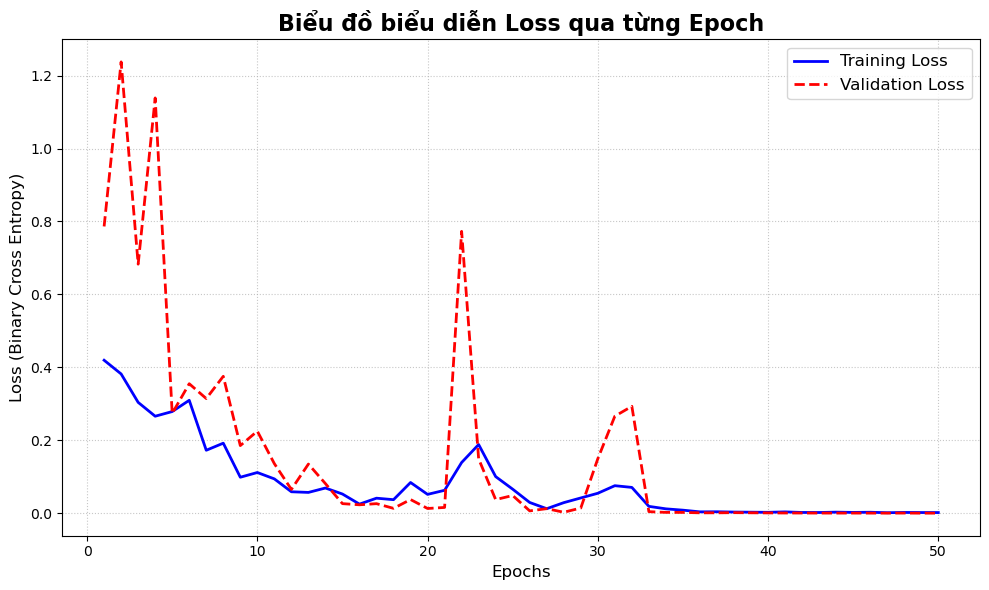

In [29]:
epochs = range(1, len(training_costs) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, training_costs, label='Training Loss', color='blue', linewidth=2)

if validation_costs:
    plt.plot(epochs, validation_costs, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.title('Biểu đồ biểu diễn Loss qua từng Epoch', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Binary Cross Entropy)', fontsize=12)

plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
from functions.score import accuracy_score

X_test_indices = np.zeros((X_test.shape[0], maxLen))
for i in range(X_test.shape[0]):
    sentence_words = X_test[i].lower().split()
    j = 0

    for w in sentence_words:
        if w in word_to_index:
            X_test_indices[i, j] = word_to_index[w]
            j += 1

X_test_indices = X_test_indices.astype(np.int32)

print(X_test_indices.shape)
print(X_test_indices)

(55, 10)
[[175199 123517 264550  56160      0      0      0      0      0      0]
 [175199 164934  43010 377946 260760 299527      0      0      0      0]
 [327864 164934 239105  43010 260760 291753      0      0      0      0]
 [170403 170403 170403 193716 383514 336114 155345      0      0      0]
 [175199 192973  43010 164328 154049      0      0      0      0      0]
 [185457  52943 373561      0      0      0      0      0      0      0]
 [384374 170714 346373  43010 226326 124461 361859      0      0      0]
 [386432 192973 357266 151204      0      0      0      0      0      0]
 [343812 231552 358160 198514 170403 170403 170403      0      0      0]
 [386432 192973 357266  67287      0      0      0      0      0      0]
 [389836 192973 173236      0      0      0      0      0      0      0]
 [358160 161844 192973 241923 388711 239105      0      0      0      0]
 [ 58997 394475 325573      0      0      0      0      0      0      0]
 [220870 374021 163237 286375  69714      

In [31]:
y_pred = model.predict(X_test_indices)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.7090909090909091
